In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt

In [3]:
train_data = datasets.MNIST(
    root="train_data",
    train=True,
    download=True,
    transform=transforms.ToTensor()
)

100%|██████████| 9.91M/9.91M [00:00<00:00, 61.4MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 1.62MB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 15.3MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 9.03MB/s]


In [4]:
test_dataset = datasets.MNIST(
    root="test_data",
    train=False,
    download=True,
    transform=transforms.ToTensor()
)

100%|██████████| 9.91M/9.91M [00:00<00:00, 60.3MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 1.65MB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 14.8MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 9.41MB/s]


In [5]:
model = nn.Sequential(
    nn.Conv2d(1, 32, 3),
    nn.ReLU(),
    nn.MaxPool2d(2),

    nn.Conv2d(32, 64, 3),
    nn.ReLU(),
    nn.MaxPool2d(2),

    nn.Flatten(),

    nn.Linear(64 * 5 * 5, 128),
    nn.ReLU(),

    nn.Linear(128, 10)
)

In [6]:
train_data_loader = DataLoader(dataset=train_data,
                        batch_size=32,
                        shuffle=True)

In [7]:
loss_fn = nn.CrossEntropyLoss()

In [8]:
optemizer = optim.Adam(params=model.parameters(), lr=0.001)

In [9]:
for echo in range(3):
  for img, label in train_data_loader:
    optemizer.zero_grad()

    output = model(img)
    loss = loss_fn(output, label)

    loss.backward()
    optemizer.step()

In [10]:
img, label = test_dataset[0]

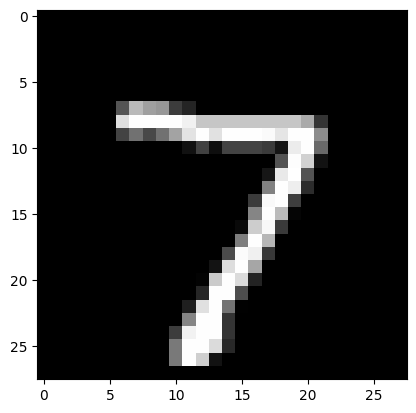

In [11]:
plt.imshow(img.squeeze(0), cmap='gray')

In [12]:
print("prediction: ", torch.argmax(model(img.unsqueeze(0))))
print("label: ", label)

prediction:  tensor(7)
label:  7


In [14]:
torch.save(model.state_dict(), 'Digit_Recognition.pth')